# CNN Deep Conv1D baseline

This notebook contains the selected CNN architecture for the forecasting practice.

The model receives a tensor with shape:

```text
X = samples × input_window × 23 assets
```

and predicts:

```text
y = samples × 23 assets
```

By default, the experiment uses `input_window = 30` and `output_window = 5`, because this was the first validated CNN setup. The model is trained with MAE, uses a validation split taken from the training set, and keeps the test set untouched for final evaluation.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

import keras
from keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    SpatialDropout1D,
    GlobalAveragePooling1D,
    GlobalMaxPooling1D,
    Concatenate,
    Dense,
    Dropout,
)
from keras.models import Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "util.py").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing util.py and data/")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from util import get_train_test, RANDOM_SEED

np.random.seed(RANDOM_SEED)
keras.utils.set_random_seed(RANDOM_SEED)

OUTPUT_DIR = PROJECT_ROOT / "model" / "CNN" / "outputs" / "cnn_deep"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output dir:", OUTPUT_DIR)

I0000 00:00:1777829770.077844 1761573 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777829770.078149 1761573 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Project root: /home/hugo/Desktop/Neural-Networks-Forecasting
Output dir: /home/hugo/Desktop/Neural-Networks-Forecasting/model/CNN/outputs/cnn_deep


I0000 00:00:1777829770.847276 1761573 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777829770.847467 1761573 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Configuration

The default window is `30 → 5`: the model observes 30 past days and predicts the average return over the following 5 days. You can change these values to run another combination required by the practice.

In [2]:
INPUT_WINDOW = 30
OUTPUT_WINDOW = 5

EPOCHS = 150
BATCH_SIZE = 128
VALIDATION_RATIO = 0.10

## Data split and scaling

The repository already provides `get_train_test`, which builds the time windows. We create a validation set from the last part of the training data and fit the scaler only on training observations to avoid leakage.

In [3]:
def split_train_val(X_train, y_train, val_ratio=0.10):
    val_size = int(len(X_train) * val_ratio)
    if val_size <= 0:
        raise ValueError("Validation split is empty. Increase training size or val_ratio.")

    X_val = X_train[-val_size:]
    y_val = y_train[-val_size:]
    X_train_final = X_train[:-val_size]
    y_train_final = y_train[:-val_size]
    return X_train_final, y_train_final, X_val, y_val


def scale_X_only(X_train, X_val, X_test):
    n_train, window, n_assets = X_train.shape
    n_val = X_val.shape[0]
    n_test = X_test.shape[0]

    scaler = StandardScaler()
    X_train_2d = X_train.reshape(n_train, -1)
    X_val_2d = X_val.reshape(n_val, -1)
    X_test_2d = X_test.reshape(n_test, -1)

    X_train_scaled = scaler.fit_transform(X_train_2d).reshape(n_train, window, n_assets)
    X_val_scaled = scaler.transform(X_val_2d).reshape(n_val, window, n_assets)
    X_test_scaled = scaler.transform(X_test_2d).reshape(n_test, window, n_assets)
    return X_train_scaled, X_val_scaled, X_test_scaled


d = get_train_test(INPUT_WINDOW, OUTPUT_WINDOW)

X_train_raw, y_train_raw = d.X_train, d.y_train
X_test_raw, y_test = d.X_test, d.y_test

X_train_raw, y_train, X_val_raw, y_val = split_train_val(
    X_train_raw, y_train_raw, val_ratio=VALIDATION_RATIO
)
X_train, X_val, X_test = scale_X_only(X_train_raw, X_val_raw, X_test_raw)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train: (13082, 30, 23)
y_train: (13082, 23)
X_val:   (1453, 30, 23)
y_val:   (1453, 23)
X_test:  (1616, 30, 23)
y_test:  (1616, 23)


## CNN architecture

This is the deeper CNN selected after the first exploratory run. It uses causal `Conv1D` layers, dilations to capture a wider temporal context, pooling layers to summarize the sequence, and dense layers to produce one prediction per asset.

In [4]:
def build_deep_cnn(input_window, n_assets):
    inputs = Input(shape=(input_window, n_assets))

    x = Conv1D(filters=64, kernel_size=3, padding="causal", activation="relu")(inputs)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.10)(x)

    x = Conv1D(filters=64, kernel_size=5, padding="causal", dilation_rate=2, activation="relu")(x)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.10)(x)

    x = Conv1D(filters=128, kernel_size=3, padding="causal", dilation_rate=4, activation="relu")(x)
    x = BatchNormalization()(x)

    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    x = Concatenate()([avg_pool, max_pool])

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.25)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.15)(x)

    outputs = Dense(n_assets, activation="linear")(x)
    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss="mae",
        metrics=["mae"],
    )
    return model


model = build_deep_cnn(INPUT_WINDOW, X_train.shape[2])
model.summary()

E0000 00:00:1777829773.032139 1761573 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 23)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │      4,480 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 30, 64)    │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 64)    │     20,544 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 30, 64)    │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 30, 128)   │     24,704 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 128)   │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 23)        │      1,495 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 93,399 (364.84 KB)

 Trainable params: 92,887 (362.84 KB)

 Non-trainable params: 512 (2.00 KB)

## Training

We use `EarlyStopping` to stop when validation MAE no longer improves and `ReduceLROnPlateau` to reduce the learning rate when the validation loss reaches a plateau.

In [5]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=20,
        min_delta=1e-6,
        restore_best_weights=True,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
    ),
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
    shuffle=True,
)

Epoch 1/150


  1/103 ━━━━━━━━━━━━━━━━━━━━ 2:12 1s/step - loss: 1.9893 - mae: 1.9893

  7/103 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.7419 - mae: 1.7419

 12/103 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.6001 - mae: 1.6001

 18/103 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.4628 - mae: 1.4628

...

 79/103 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0055 - mae: 0.0055

 85/103 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0055 - mae: 0.0055

 91/103 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0055 - mae: 0.0055

 97/103 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0055 - mae: 0.0055

103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0055 - mae: 0.0055 - val_loss: 0.0042 - val_mae: 0.0042 - learning_rate: 7.5000e-05


## Evaluation and saved outputs

The model is evaluated on train, validation and test. The notebook also compares the test MAE against the linear regression benchmark provided in the repository when available.

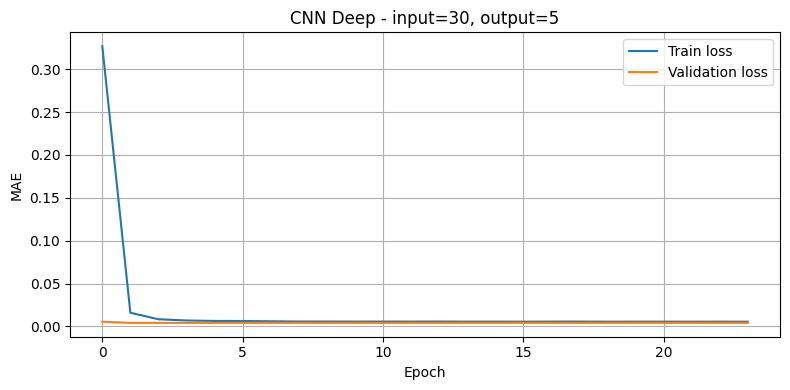

Results saved to: /home/hugo/Desktop/Neural-Networks-Forecasting/model/CNN/outputs/cnn_deep/cnn_deep_30_5_results.csv
History saved to: /home/hugo/Desktop/Neural-Networks-Forecasting/model/CNN/outputs/cnn_deep/cnn_deep_30_5_history.csv
Model saved to: /home/hugo/Desktop/Neural-Networks-Forecasting/model/CNN/outputs/cnn_deep/cnn_deep_30_5.keras
Curve saved to: /home/hugo/Desktop/Neural-Networks-Forecasting/model/CNN/outputs/cnn_deep/cnn_deep_30_5_training_curve.png


,model,input_window,output_window,MAE_train,MAE_val,MAE_test,params,epochs_trained
0,CNN_Deep_Conv1D,30,5,0.005477,0.004153,0.005577,93399,24


,model,input_window,output_window,MAE_train,MAE_val,MAE_test,params,epochs_trained,improvement_abs_vs_lr,improvement_pct_vs_lr
0,Linear_Regression_Benchmark,30,5,0.005337,NaN,0.005877,NaN,NaN,0.0000,0.000000
1,CNN_Deep_Conv1D,30,5,0.005477,0.004153,0.005577,93399.0,24.0,0.0003,5.105619


In [6]:
y_pred_train = model.predict(X_train, verbose=0)
y_pred_val = model.predict(X_val, verbose=0)
y_pred_test = model.predict(X_test, verbose=0)

result = {
    "model": "CNN_Deep_Conv1D",
    "input_window": INPUT_WINDOW,
    "output_window": OUTPUT_WINDOW,
    "MAE_train": mean_absolute_error(y_train, y_pred_train),
    "MAE_val": mean_absolute_error(y_val, y_pred_val),
    "MAE_test": mean_absolute_error(y_test, y_pred_test),
    "params": model.count_params(),
    "epochs_trained": len(history.history["loss"]),
}

results_df = pd.DataFrame([result])
results_path = OUTPUT_DIR / f"cnn_deep_{INPUT_WINDOW}_{OUTPUT_WINDOW}_results.csv"
results_df.to_csv(results_path, index=False)

history_df = pd.DataFrame(history.history)
history_path = OUTPUT_DIR / f"cnn_deep_{INPUT_WINDOW}_{OUTPUT_WINDOW}_history.csv"
history_df.to_csv(history_path, index=False)

model_path = OUTPUT_DIR / f"cnn_deep_{INPUT_WINDOW}_{OUTPUT_WINDOW}.keras"
model.save(model_path)

curve_path = OUTPUT_DIR / f"cnn_deep_{INPUT_WINDOW}_{OUTPUT_WINDOW}_training_curve.png"
plt.figure(figsize=(8, 4))
plt.plot(history_df["loss"], label="Train loss")
plt.plot(history_df["val_loss"], label="Validation loss")
plt.title(f"CNN Deep - input={INPUT_WINDOW}, output={OUTPUT_WINDOW}")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(curve_path, dpi=150)
plt.show()

comparison_df = None
lr_path = PROJECT_ROOT / "data" / "lr_benchmark.csv"
if lr_path.exists():
    lr = pd.read_csv(lr_path)
    lr_match = lr[(lr["input_window"] == INPUT_WINDOW) & (lr["output_window"] == OUTPUT_WINDOW)]
    if len(lr_match) == 1:
        lr_row = lr_match.iloc[0]
        comparison_df = pd.DataFrame([
            {
                "model": "Linear_Regression_Benchmark",
                "input_window": INPUT_WINDOW,
                "output_window": OUTPUT_WINDOW,
                "MAE_train": lr_row["MAE_train"],
                "MAE_val": np.nan,
                "MAE_test": lr_row["MAE_test"],
                "params": np.nan,
                "epochs_trained": np.nan,
            },
            result,
        ])
        comparison_df["improvement_abs_vs_lr"] = comparison_df["MAE_test"].iloc[0] - comparison_df["MAE_test"]
        comparison_df["improvement_pct_vs_lr"] = (
            comparison_df["improvement_abs_vs_lr"] / comparison_df["MAE_test"].iloc[0] * 100
        )
        comparison_path = OUTPUT_DIR / f"cnn_deep_{INPUT_WINDOW}_{OUTPUT_WINDOW}_comparison_vs_lr.csv"
        comparison_df.to_csv(comparison_path, index=False)

print("Results saved to:", results_path)
print("History saved to:", history_path)
print("Model saved to:", model_path)
print("Curve saved to:", curve_path)

display(results_df)
if comparison_df is not None:
    display(comparison_df)

## Interpretation

In the exploratory run, this architecture improved the linear regression benchmark for `30 → 5` with a test MAE around `0.00558` versus the benchmark around `0.00588`. The validation curve tends to become flat quickly because the target returns are centered close to zero, so a conservative prediction already gives a competitive MAE.